In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [3]:
df = pd.read_csv('/content/drive/MyDrive/clean_steam_dataset.csv')
print(f"Ucitano recenzija: {len(df)}")
print("\nPrvih 5 redova:")
print(df.head())
print("\nKolone:")
print(df.columns.tolist())
print("\nRaspodela review_score:")
print(df['review_score'].value_counts())

Ucitano recenzija: 43160

Prvih 5 redova:
             app_name  review_score  \
0            PAYDAY 2             1   
1  Grand Theft Auto V             1   
2              Arma 3             1   
3            PAYDAY 2             1   
4  Grand Theft Auto V            -1   

                                         review_text  
0  This game is great! I think anybody would love...  
1  I havent seen my friends or socialized since A...  
2  Well,the price is a little bit highwith all th...  
3  Shot a swat members helmet off, and it flew ar...  
4  I became Master of PC programming after Grand ...  

Kolone:
['app_name', 'review_score', 'review_text']

Raspodela review_score:
review_score
-1    21585
 1    21575
Name: count, dtype: int64


In [4]:
#LSTM uzima 0 i 1 kao output oznake
df['label'] = df['review_score'].apply(lambda x: 1 if x == 1 else 0)

X = df['review_text'].values
y = df['label'].values

print(f"Broj recenzija: {len(X)}")
print(f"Procenat pozitivnih (1): {y.sum() / len(y) * 100:.1f}%")
print(f"Odnos klasa - 0: {(y == 0).sum()}, 1: {(y == 1).sum()}")

Broj recenzija: 43160
Procenat pozitivnih (1): 50.0%
Odnos klasa - 0: 21585, 1: 21575


In [5]:
#odvojiti 10% podataka za test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

#odvajamo validaciju i train
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, random_state=42, stratify=y_temp)

print(f"Trening: {len(X_train)} recenzija")
print(f"Validacija: {len(X_val)} recenzija")
print(f"Test: {len(X_test)} recenzija")
print(f"\nOdnos klasa u treningu - 0: {(y_train == 0).sum()}, 1: {(y_train == 1).sum()}")

Trening: 34528 recenzija
Validacija: 4316 recenzija
Test: 4316 recenzija

Odnos klasa u treningu - 0: 17268, 1: 17260


In [6]:
max_words = 20000

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

train_lengths = [len(seq) for seq in X_train_seq]
percentile_95 = np.percentile(train_lengths, 95)

max_len = int(percentile_95)  # = 275

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

In [ ]:
model1 = Sequential()
model1.add(Embedding(input_dim=max_words, output_dim=64))
model1.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model1.add(Dense(1, activation='sigmoid'))

model1.build(input_shape=(None, max_len))
model1.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

callbacks1 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/checkpoints/model1_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history1 = model1.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=20, batch_size=32, callbacks=callbacks1, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 275, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,089 (5.01 MB)

 Trainable params: 1,313,089 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.5095 - loss: 0.6933
Epoch 1: val_loss improved from None to 0.69076, saving model to /content/drive/MyDrive/checkpoints/model1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/model1_best.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 631s 577ms/step - accuracy: 0.5092 - loss: 0.6925 - val_accuracy: 0.5178 - val_loss: 0.6908
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.5204 - loss: 0.6877
Epoch 2: val_loss improved from 0.69076 to 0.68984, saving model to /content/drive/MyDrive/checkpoints/model1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoints/model1_best.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 672s 572ms/step - accuracy: 0.5189 - loss: 0.6863 - val_accuracy: 0.5155 - val_loss: 0.6898
Epoch 3/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 592ms/step - accuracy: 0.5147 - loss: 0.6798
Epoch 3: val_loss did not improve from 0.68984
1079/1079 ━━━━━━━━━━━━

In [ ]:
model2 = Sequential()
model2.add(Embedding(input_dim=max_words, output_dim=128))
model2.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model2.add(Dense(1, activation='sigmoid'))

model2.build(input_shape=(None, max_len))
model2.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/checkpoints/model2_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history2 = model2.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=20, batch_size=32, callbacks=callbacks2, verbose=1)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 275, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691,713 (10.27 MB)

 Trainable params: 2,691,713 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.5060 - loss: 0.6929
Epoch 1: val_loss improved from None to 0.69195, saving model to /content/drive/MyDrive/checkpoints/model2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/model2_best.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 714s 659ms/step - accuracy: 0.5106 - loss: 0.6918 - val_accuracy: 0.5155 - val_loss: 0.6920
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.5121 - loss: 0.6874
Epoch 2: val_loss improved from 0.69195 to 0.68995, saving model to /content/drive/MyDrive/checkpoints/model2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoints/model2_best.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 716s 663ms/step - accuracy: 0.5131 - loss: 0.6862 - val_accuracy: 0.5188 - val_loss: 0.6900
Epoch 3/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.5233 - loss: 0.6761
Epoch 3: val_loss did not improve from 0.68995
1079/1079 ━━━━━━━━━━━━

In [7]:
model3 = Sequential()
model3.add(Embedding(input_dim=max_words, output_dim=128))
model3.add(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
model3.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model3.add(Dense(1, activation='sigmoid'))

model3.build(input_shape=(None, max_len))
model3.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

callbacks3 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/checkpoints/model3_best.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

history3 = model3.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=20, batch_size=32, callbacks=callbacks3, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 275, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 275, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,823,297 (10.77 MB)

 Trainable params: 2,823,297 (10.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5118 - loss: 0.6928
Epoch 1: val_loss improved from None to 0.69073, saving model to /content/drive/MyDrive/checkpoints/model3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/model3_best.keras
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1244s 1s/step - accuracy: 0.5084 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 2/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5100 - loss: 0.6897
Epoch 2: val_loss did not improve from 0.69073
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1251s 1s/step - accuracy: 0.5141 - loss: 0.6884 - val_accuracy: 0.5167 - val_loss: 0.6919
Epoch 3/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5201 - loss: 0.6801
Epoch 3: val_loss did not improve from 0.69073
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 1239s 1s/step - accuracy: 0.5226 - loss: 0.6805 - val_accuracy: 0.5155 - val_loss: 0.6910
Epoch 4/20
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5257 - lo

In [7]:
model4 = Sequential()
model4.add(Embedding(input_dim=max_words, output_dim=128))
model4.add(Bidirectional(LSTM(128, recurrent_dropout=0.2, return_sequences=True)))
model4.add(Dropout(0.4))
model4.add(Bidirectional(LSTM(64, recurrent_dropout=0.2, return_sequences=False)))
model4.add(BatchNormalization())
model4.add(Dense(64, activation='relu'))
model4.add(Dropout(0.4))
model4.add(Dense(1, activation='sigmoid'))

model4.build(input_shape=(None, max_len))
model4.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
model4.summary()

os.makedirs('/content/drive/MyDrive/checkpoints', exist_ok=True)

callbacks4 = [
    ModelCheckpoint('/content/drive/MyDrive/checkpoints/model4_best.keras', monitor='val_loss', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history4 = model4.fit(X_train_pad, y_train, validation_data=(X_val_pad, y_val),
                      epochs=20, batch_size=128, callbacks=callbacks4, verbose=1)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 275, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 275, 256)       │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 275, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,996,353 (11.43 MB)

 Trainable params: 2,996,097 (11.43 MB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7050 - loss: 0.5520
Epoch 1: val_loss improved from None to 0.46548, saving model to /content/drive/MyDrive/checkpoints/model4_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/model4_best.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 1540s 6s/step - accuracy: 0.7669 - loss: 0.4895 - val_accuracy: 0.8119 - val_loss: 0.4655 - learning_rate: 0.0010
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8291 - loss: 0.3941
Epoch 2: val_loss improved from 0.46548 to 0.46166, saving model to /content/drive/MyDrive/checkpoints/model4_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoints/model4_best.keras
270/270 ━━━━━━━━━━━━━━━━━━━━ 1531s 6s/step - accuracy: 0.8182 - loss: 0.4117 - val_accuracy: 0.8237 - val_loss: 0.4617 - learning_rate: 0.0010
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8645 - loss: 0.3389
Epoch 3: val_loss improved from 0.46166 to 0

Model 3 ucitan sa Drive-a.
Model 4 ucitan sa Drive-a.
Evaluacija modela na testnom skupu:
------------------------------

Model 1 (LSTM 64):
  Accuracy:  0.5183
  Precision: 0.5094
  Recall:    0.9787
  F1:        0.6701


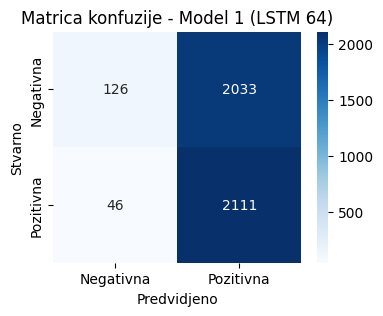


Model 2 (LSTM 128):
  Accuracy:  0.5192
  Precision: 0.5100
  Recall:    0.9666
  F1:        0.6677


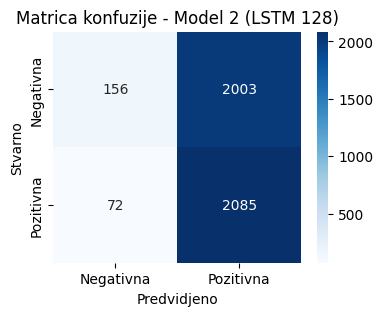


Model 3 (2xLSTM 128):
  Accuracy:  0.5169
  Precision: 0.5088
  Recall:    0.9634
  F1:        0.6659


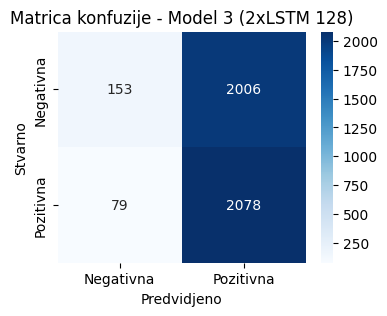


Model 4 (dvosmerni LSTM):
  Accuracy:  0.8480
  Precision: 0.8447
  Recall:    0.8526
  F1:        0.8486


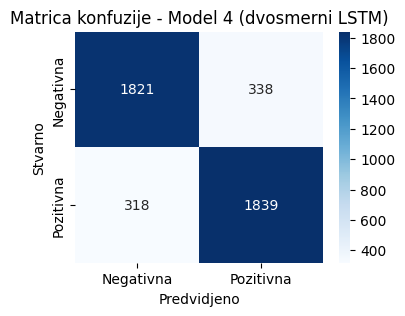

Pregled rezultata:
------------------------------
                   Model  Accuracy  Precision   Recall       F1
       Model 1 (LSTM 64)  0.518304   0.509411 0.978674 0.670052
      Model 2 (LSTM 128)  0.519231   0.510029 0.966620 0.667734
    Model 3 (2xLSTM 128)  0.516914   0.508815 0.963375 0.665919
Model 4 (dvosmerni LSTM)  0.848007   0.844740 0.852573 0.848639


In [8]:
#evaluacija modela na test skupu

model1 = load_model('/content/drive/MyDrive/checkpoints/model1_best.keras')
model2 = load_model('/content/drive/MyDrive/checkpoints/model2_best.keras')

try:
    model3 = load_model('/content/drive/MyDrive/checkpoints/model3_best.keras')
    print("Model 3 ucitan sa Drive-a.")
except:
    print("Model 3 nije pronadjen na Drive-u, koristi se trenutno istrenirani model.")

try:
    model4 = load_model('/content/drive/MyDrive/checkpoints/model4_best.keras')
    print("Model 4 ucitan sa Drive-a.")
except:
    print("Model 4 nije pronadjen na Drive-u, koristi se trenutno istrenirani model.")

models = [model1, model2, model3, model4]
names = ['Model 1 (LSTM 64)', 'Model 2 (LSTM 128)', 'Model 3 (2xLSTM 128)', 'Model 4 (dvosmerni LSTM)']

print("Evaluacija modela na testnom skupu:")
print("-"*30)

results = []

for name, model in zip(names, models):
    y_prob = model.predict(X_test_pad, batch_size=256, verbose=0)
    y_pred = (y_prob >= 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negativna', 'Pozitivna'], yticklabels=['Negativna', 'Pozitivna'])
    plt.title(f'Matrica konfuzije - {name}')
    plt.xlabel('Predvidjeno')
    plt.ylabel('Stvarno')
    plt.show()

print("Pregled rezultata:")
print("-"*30)
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1'])
print(results_df.to_string(index=False))